Importing libraries 


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  

In [48]:
df =  pd.read_csv("Dataset_1.csv")

In [49]:
df.head()

,accident_id,accident_datetime,state,district,area_type,latitude,longitude,road_type,road_condition,road_lighting,...,ambulance_called,police_called,response_time_minutes,hospitalization_required,num_vehicles,num_injuries,num_fatalities,accident_severity,insurance_claim_filed,insurance_claim_amount
0,ACC20240000709,2024-12-15 15:14:47,Karnataka,Hubli District,Rural,15.741067,74.555047,State Highway,Pothole-Ridden,Streetlight Absent,...,No,Yes,86.178166,Yes,2,3,1,Severe,No,NaN
1,ACC20200196249,2020-09-09 21:36:54,Haryana,Faridabad District,Urban,30.211127,75.461897,Other District Road,Dry,Streetlight Absent,...,No,No,NaN,No,2,0,0,Minor,Yes,26761.0
2,ACC20180059148,2018-07-24 16:43:57,West Bengal,Siliguri District,Semi-Urban,23.782972,86.281103,State Highway,Under Construction,Streetlight Absent,...,No,No,NaN,No,5,2,0,Moderate,Yes,9295.0
3,ACC20160076737,2016-11-17 17:53:16,West Bengal,Howrah District,Rural,24.872909,87.339504,National Highway,Dry,Streetlight Absent,...,Yes,Yes,16.943981,No,1,0,0,Minor,Yes,48147.0
4,ACC20230004919,2023-03-18 23:35:24,Rajasthan,Jodhpur District,Semi-Urban,24.305082,74.252979,State Highway,Dry,Streetlight Present,...,No,No,NaN,No,3,0,0,Minor,Yes,20636.0


In [50]:
df.shape

(202000, 48)

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 202000 entries, 0 to 201999
Data columns (total 48 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   accident_id                202000 non-null  str    
 1   accident_datetime          202000 non-null  str    
 2   state                      202000 non-null  str    
 3   district                   195938 non-null  str    
 4   area_type                  202000 non-null  str    
 5   latitude                   192022 non-null  float64
 6   longitude                  192022 non-null  float64
 7   road_type                  202000 non-null  str    
 8   road_condition             202000 non-null  str    
 9   road_lighting              195936 non-null  str    
 10  number_of_lanes            193914 non-null  float64
 11  speed_limit_kmph           191888 non-null  float64
 12  estimated_speed_kmph       202000 non-null  float64
 13  junction_type              195935 non-nu

In [52]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
201995    False
201996    False
201997    False
201998    False
201999    False
Length: 202000, dtype: bool

In [53]:
df.duplicated().sum()

980

In [54]:
df["accident_id"].duplicated().sum()

2000

In [55]:
# there are total 2000 duplicte accident ids 
# where as 980 of the rows were completely duplicate where as 1020 were only duplictae accident ids 

In [56]:
df = df.drop_duplicates()

In [57]:
df.shape

(201020, 48)

In [58]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,191084.0,21.761686,8.746626,-89.993206,17.833633,23.359781,26.643660,89.967149
longitude,191084.0,77.980009,15.199619,-179.316379,75.582829,77.914638,82.084662,179.807326
number_of_lanes,192974.0,2.847715,1.421421,1.000000,2.000000,2.000000,4.000000,6.000000
speed_limit_kmph,190952.0,58.829287,23.127486,20.000000,40.000000,60.000000,70.000000,120.000000
estimated_speed_kmph,201020.0,61.665766,29.595935,5.000000,39.900000,57.300000,78.200000,160.000000
visibility_km,188963.0,4.912544,2.851271,0.020000,2.660000,4.700000,7.360000,10.850000
temperature_c,190971.0,22.200665,8.148013,2.000000,15.600000,22.300000,28.800000,47.000000
rainfall_mm,201020.0,3.488557,10.438547,0.000000,0.000000,0.000000,0.000000,252.100000
driver_age,173064.0,36.481735,12.819477,13.000000,27.000000,36.000000,45.000000,102.000000
driving_experience_years,173064.0,16.723991,11.906184,0.000000,7.100000,16.000000,24.900000,55.000000


In [59]:
df.describe(include='object')

C:\Users\pushk\AppData\Local\Temp\ipykernel_11676\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,accident_id,accident_datetime,state,district,area_type,road_type,road_condition,road_lighting,junction_type,traffic_signal_present,...,vehicle_condition,overloading_status,primary_cause,secondary_cause,emergency_services_called,ambulance_called,police_called,hospitalization_required,accident_severity,insurance_claim_filed
count,201020,201020,201020,194988,201020,201020,201020,194987,194986,192988,...,201020,190970,201020,62630,201020,201020,201020,192980,201020,201020
unique,200000,199922,21,87,3,20,5,2,6,8,...,4,4,13,13,2,2,2,2,4,3
top,ACC20180059148,2018-07-24 16:43:57,Uttar Pradesh,Kanpur District,Urban,Other District Road,Dry,Streetlight Present,No Junction,No,...,Good,Not Applicable,Weather,Overspeeding,No,No,No,No,Minor,Yes
freq,2,2,28645,4707,90630,54001,124507,116916,68148,118740,...,88766,156442,26292,9721,105255,139653,119682,137531,110536,95419


In [60]:
num_cols = df.describe().columns
non_num_cols = df.drop(num_cols,axis=1).columns
len(num_cols),len(non_num_cols)

(16, 32)

In [61]:
print(num_cols)
print(non_num_cols)

Index(['latitude', 'longitude', 'number_of_lanes', 'speed_limit_kmph',
       'estimated_speed_kmph', 'visibility_km', 'temperature_c', 'rainfall_mm',
       'driver_age', 'driving_experience_years', 'vehicle_age_years',
       'response_time_minutes', 'num_vehicles', 'num_injuries',
       'num_fatalities', 'insurance_claim_amount'],
      dtype='str')
Index(['accident_id', 'accident_datetime', 'state', 'district', 'area_type',
       'road_type', 'road_condition', 'road_lighting', 'junction_type',
       'traffic_signal_present', 'median_present', 'weather_condition',
       'driver_gender', 'license_status', 'alcohol_involved',
       'distraction_involved', 'mobile_phone_used', 'fatigue_involved',
       'helmet_seatbelt_used', 'vehicle_type', 'vehicle_brand',
       'vehicle_model', 'vehicle_condition', 'overloading_status',
       'primary_cause', 'secondary_cause', 'emergency_services_called',
       'ambulance_called', 'police_called', 'hospitalization_required',
       'accide

In [62]:
null_col = df.isnull().sum()
null_col

accident_id                       0
accident_datetime                 0
state                             0
district                       6032
area_type                         0
latitude                       9936
longitude                      9936
road_type                         0
road_condition                    0
road_lighting                  6033
number_of_lanes                8046
speed_limit_kmph              10068
estimated_speed_kmph              0
junction_type                  6034
traffic_signal_present         8032
median_present                 8031
weather_condition              4018
visibility_km                 12057
temperature_c                 10049
rainfall_mm                       0
driver_age                    27956
driver_gender                  6030
driving_experience_years      27956
license_status                    0
alcohol_involved                  0
distraction_involved              0
mobile_phone_used                 0
fatigue_involved            

In [63]:
null_percent  = (null_col/len(df))*100
null_percent
# percentage of the null values in each columns 

accident_id                   0.000000
accident_datetime             0.000000
state                         0.000000
district                      3.000696
area_type                     0.000000
latitude                      4.942792
longitude                     4.942792
road_type                     0.000000
road_condition                0.000000
road_lighting                 3.001194
number_of_lanes               4.002587
speed_limit_kmph              5.008457
estimated_speed_kmph          0.000000
junction_type                 3.001691
traffic_signal_present        3.995622
median_present                3.995125
weather_condition             1.998806
visibility_km                 5.997911
temperature_c                 4.999005
rainfall_mm                   0.000000
driver_age                   13.907074
driver_gender                 2.999702
driving_experience_years     13.907074
license_status                0.000000
alcohol_involved              0.000000
distraction_involved     

In [64]:
df_null = pd.DataFrame({"null_percent": null_percent})
df_null =  df_null[df_null["null_percent"]>0]
df_null

,null_percent
district,3.000696
latitude,4.942792
longitude,4.942792
road_lighting,3.001194
number_of_lanes,4.002587
speed_limit_kmph,5.008457
junction_type,3.001691
traffic_signal_present,3.995622
median_present,3.995125
weather_condition,1.998806


These column contains null values with there given respective percentage null values 

In [65]:
df_null['null_percent'].sort_values()

weather_condition            1.998806
driver_gender                2.999702
district                     3.000696
road_lighting                3.001194
junction_type                3.001691
median_present               3.995125
traffic_signal_present       3.995622
hospitalization_required     3.999602
number_of_lanes              4.002587
latitude                     4.942792
longitude                    4.942792
temperature_c                4.999005
overloading_status           4.999503
speed_limit_kmph             5.008457
visibility_km                5.997911
driver_age                  13.907074
driving_experience_years    13.907074
vehicle_age_years           13.907074
vehicle_brand               19.070739
vehicle_model               21.683415
response_time_minutes       52.360462
insurance_claim_amount      54.855736
secondary_cause             68.843896
Name: null_percent, dtype: float64

In [66]:
non_num_cols = df[non_num_cols].drop(["accident_id","accident_datetime"],axis =1).columns
non_num_cols

Index(['state', 'district', 'area_type', 'road_type', 'road_condition',
       'road_lighting', 'junction_type', 'traffic_signal_present',
       'median_present', 'weather_condition', 'driver_gender',
       'license_status', 'alcohol_involved', 'distraction_involved',
       'mobile_phone_used', 'fatigue_involved', 'helmet_seatbelt_used',
       'vehicle_type', 'vehicle_brand', 'vehicle_model', 'vehicle_condition',
       'overloading_status', 'primary_cause', 'secondary_cause',
       'emergency_services_called', 'ambulance_called', 'police_called',
       'hospitalization_required', 'accident_severity',
       'insurance_claim_filed'],
      dtype='str')

In [67]:
for _ in non_num_cols:
    print(df[_].unique())

<ArrowStringArray>
[       'Karnataka',          'Haryana',      'West Bengal',
        'Rajasthan',      'Maharashtra',          'Gujarat',
    'Uttar Pradesh',           'Kerala',     'Chhattisgarh',
            'Assam', 'Himachal Pradesh',   'Andhra Pradesh',
            'Bihar',   'Madhya Pradesh',            'Delhi',
        'Jharkhand',           'Odisha',       'Tamil Nadu',
        'Telangana',           'Punjab',      'Uttarakhand']
Length: 21, dtype: str
<ArrowStringArray>
[             'Hubli District',          'Faridabad District',
           'Siliguri District',             'Howrah District',
            'Jodhpur District',             'Nagpur District',
           'Vadodara District',               'Agra District',
          'Mangaluru District',         'Aurangabad District',
             'Nashik District',                           nan,
            'Kolkata District',           'Varanasi District',
               'Durg District',             'Ambala District',
        

In [68]:
len(non_num_cols)

30

In [69]:
unique_elements = {
    col: df[col].unique() for col in non_num_cols
}

unique_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in unique_elements.items()]))
unique_df.T

,0,1,2,3,4,5,6,7,8,9,...,78,79,80,81,82,83,84,85,86,87
state,Karnataka,Haryana,West Bengal,Rajasthan,Maharashtra,Gujarat,Uttar Pradesh,Kerala,Chhattisgarh,Assam,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
district,Hubli District,Faridabad District,Siliguri District,Howrah District,Jodhpur District,Nagpur District,Vadodara District,Agra District,Mangaluru District,Aurangabad District,...,Kochi District,Roorkee District,Hyderabad District,Manali District,Bhilai District,Nainital District,Bhubaneswar District,Jamshedpur District,Dehradun District,Solan District
area_type,Rural,Urban,Semi-Urban,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
road_type,State Highway,Other District Road,National Highway,Village Road,Expressway,state highway,village road,NATIONAL HIGHWAY,National Highway,Other District Road,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
road_condition,Pothole-Ridden,Dry,Under Construction,Wet,Loose Surface,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
road_lighting,Streetlight Absent,Streetlight Present,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
junction_type,No Junction,T-Junction,Four Arm Junction,Uncontrolled Junction,NaN,Y-Junction,Roundabout,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
traffic_signal_present,Yes,No,NaN,0,N,True,False,Y,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
median_present,Yes,No,NaN,Y,N,False,True,1,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weather_condition,Clear,NaN,Rain,Rainy,Hazy,Foggy,Stormy,Foggy,rainy,Rainy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [70]:
for i in  ["road_type","weather_condition","area_type"]:
    print({i:df[i].dropna().unique().tolist()})

{'road_type': ['State Highway', 'Other District Road', 'National Highway', 'Village Road', 'Expressway', 'state highway', 'village road', 'NATIONAL HIGHWAY', ' National Highway ', ' Other District Road ', 'VILLAGE ROAD', 'OTHER DISTRICT ROAD', 'other district road', ' Village Road ', 'national highway', 'EXPRESSWAY', ' State Highway ', ' Expressway ', 'STATE HIGHWAY', 'expressway']}
{'weather_condition': ['Clear', 'Rain', 'Rainy', 'Hazy', 'Foggy', 'Stormy', ' Foggy ', 'rainy', ' Rainy ', ' Clear ', 'clear', 'CLEAR', 'foggy', 'FOGGY', 'hazy', 'RAINY', 'STORMY', 'stormy', ' Stormy ', 'HAZY', ' Hazy ']}
{'area_type': ['Rural', 'Urban', 'Semi-Urban']}


In [71]:
df["road_type"].unique()
# there are 20 different type of roads

<ArrowStringArray>
[        'State Highway',   'Other District Road',      'National Highway',
          'Village Road',            'Expressway',         'state highway',
          'village road',      'NATIONAL HIGHWAY',    ' National Highway ',
 ' Other District Road ',          'VILLAGE ROAD',   'OTHER DISTRICT ROAD',
   'other district road',        ' Village Road ',      'national highway',
            'EXPRESSWAY',       ' State Highway ',          ' Expressway ',
         'STATE HIGHWAY',            'expressway']
Length: 20, dtype: str

<Axes: xlabel='count', ylabel='road_type'>

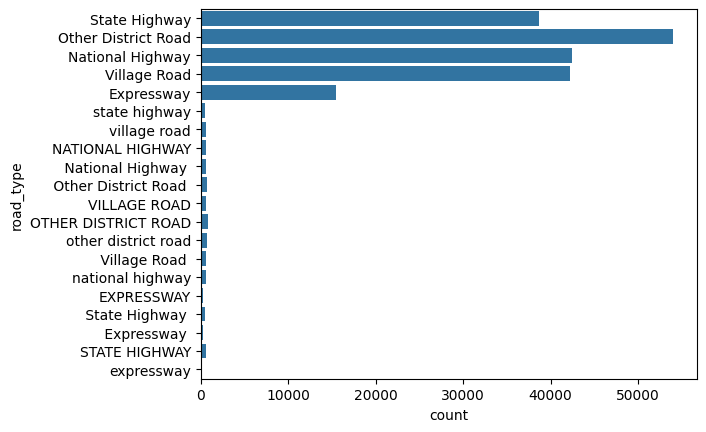

In [72]:
sns.countplot(df["road_type"])

In [73]:
dt = pd.to_datetime(df['accident_datetime'],errors='coerce')
dt

0        2024-12-15 15:14:47
1        2020-09-09 21:36:54
2        2018-07-24 16:43:57
3        2016-11-17 17:53:16
4        2023-03-18 23:35:24
                 ...        
201995   2021-04-01 20:30:23
201996   2025-02-22 19:51:03
201997   2022-09-17 10:30:59
201998   2024-06-23 16:17:20
201999   2019-06-17 13:21:45
Name: accident_datetime, Length: 201020, dtype: datetime64[us]

C:\Users\pushk\AppData\Local\Temp\ipykernel_11676\956257175.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12,6))


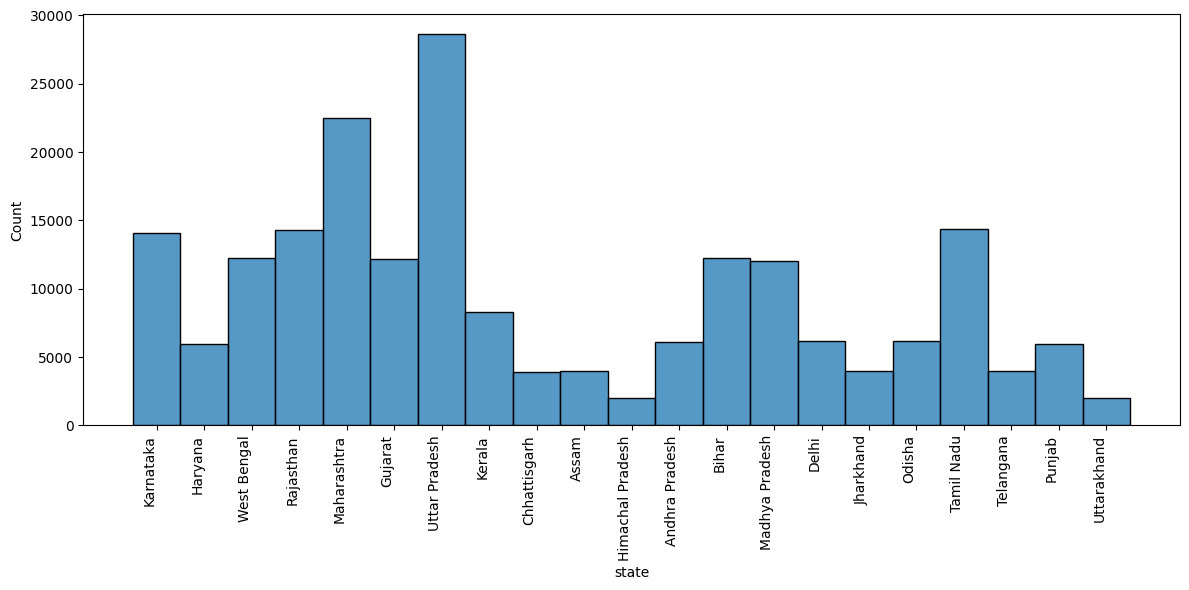

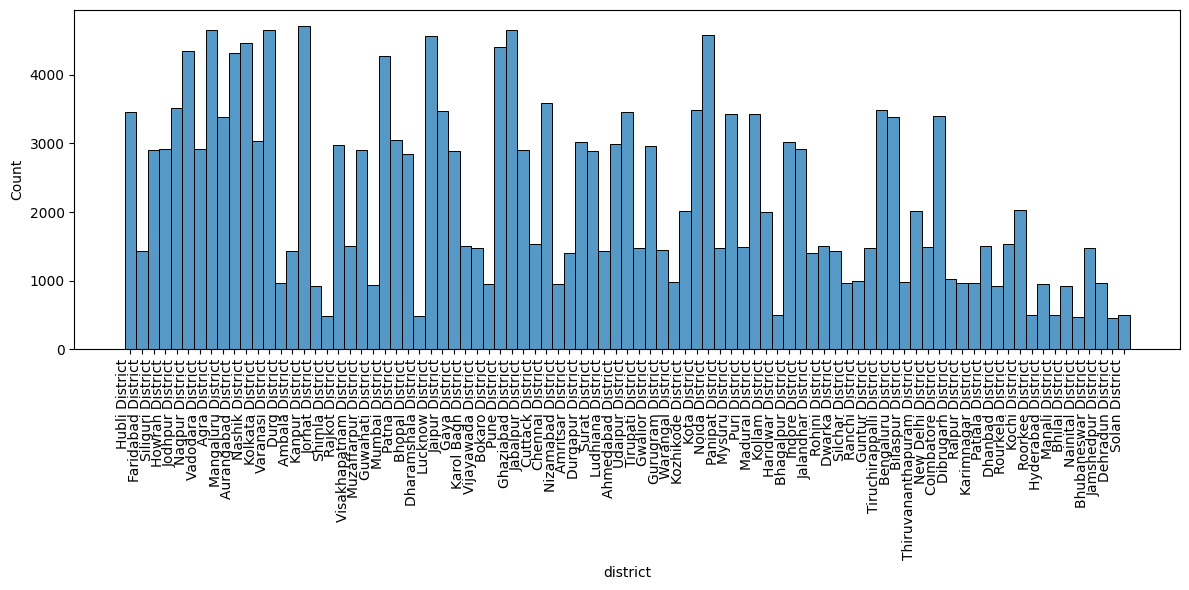

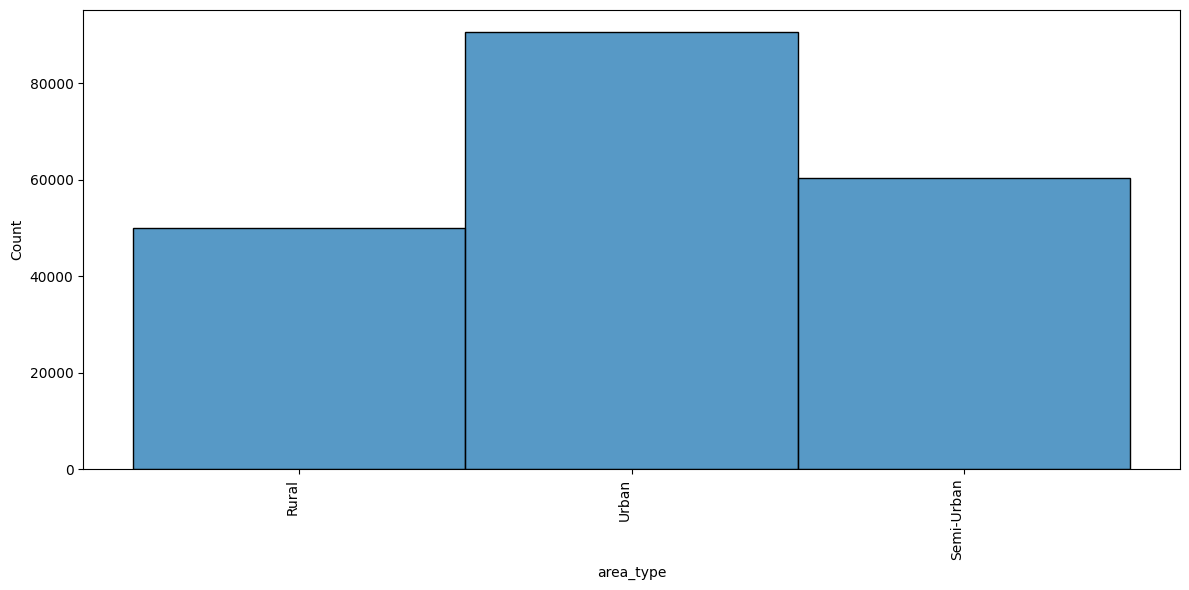

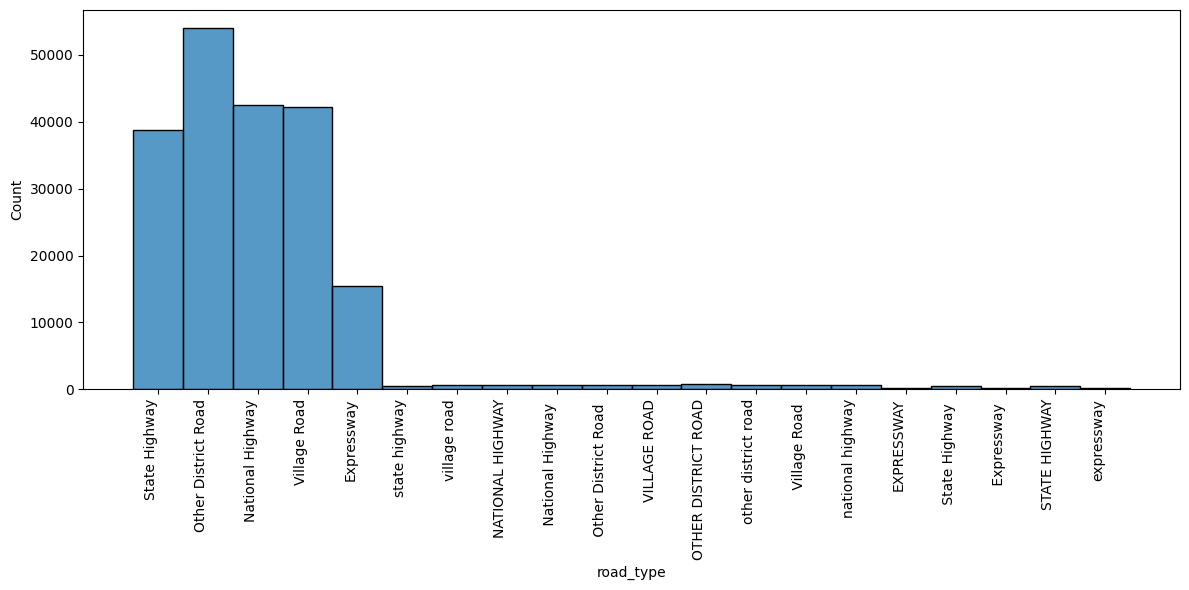

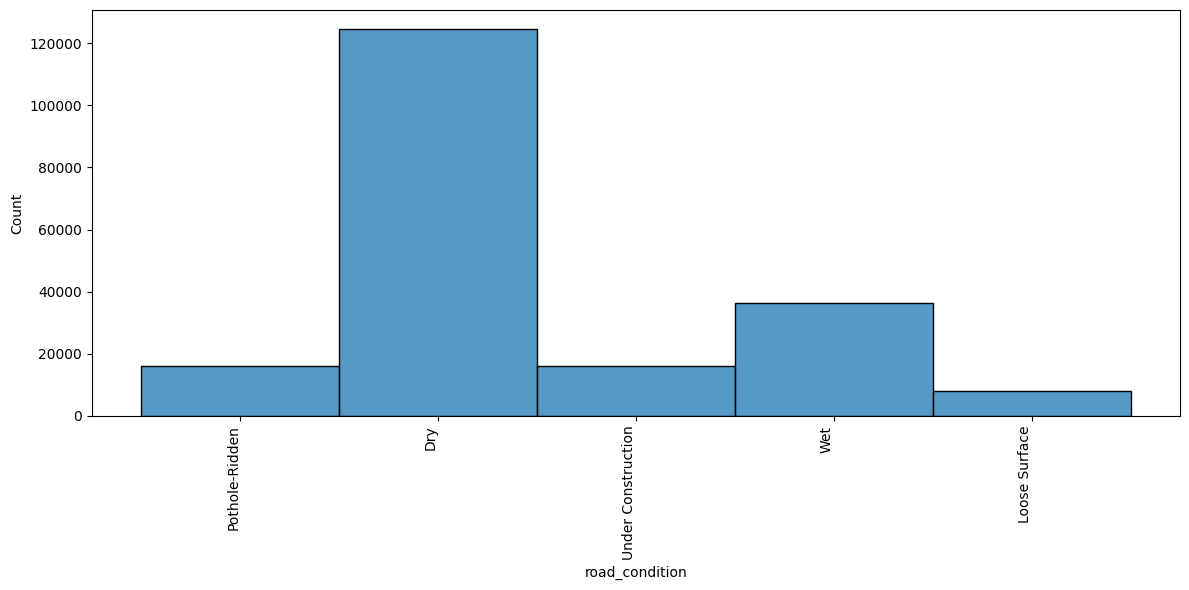

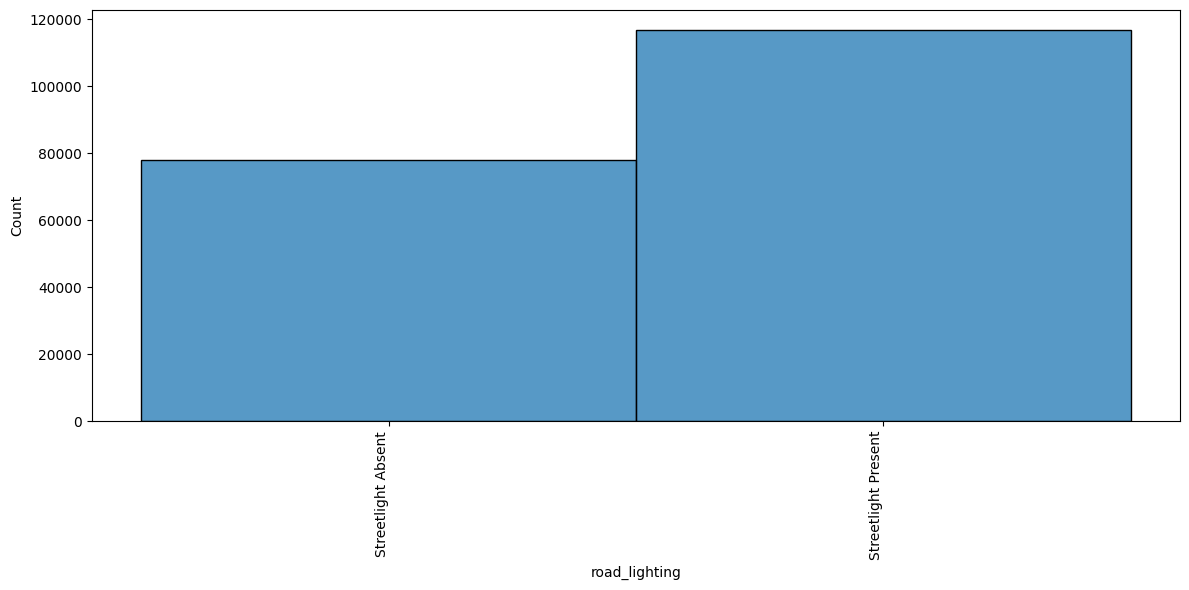

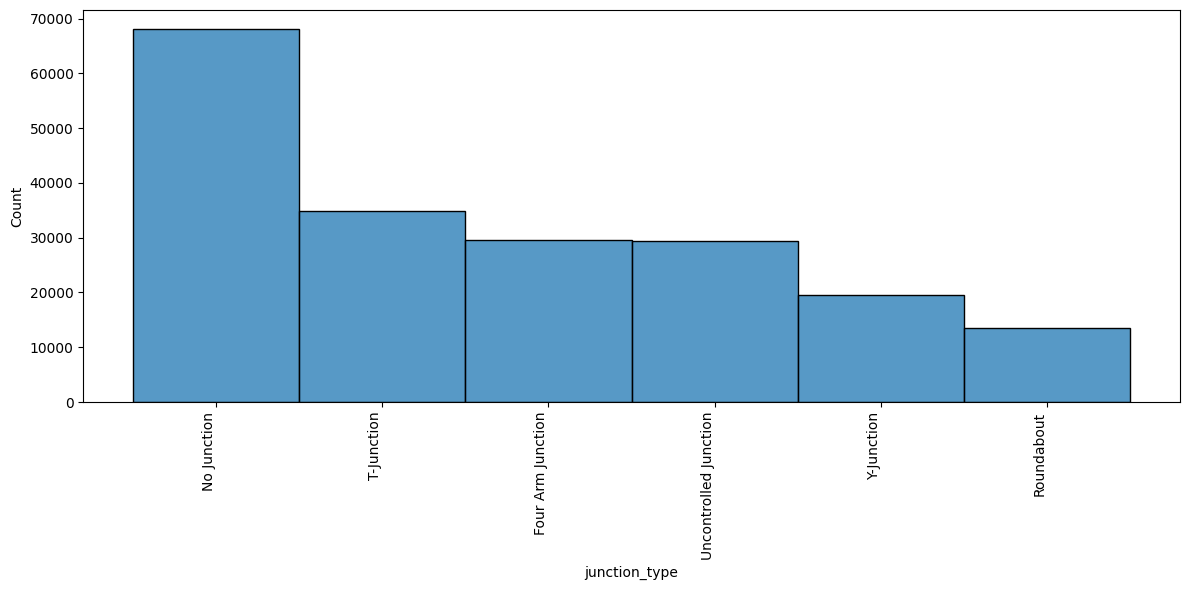

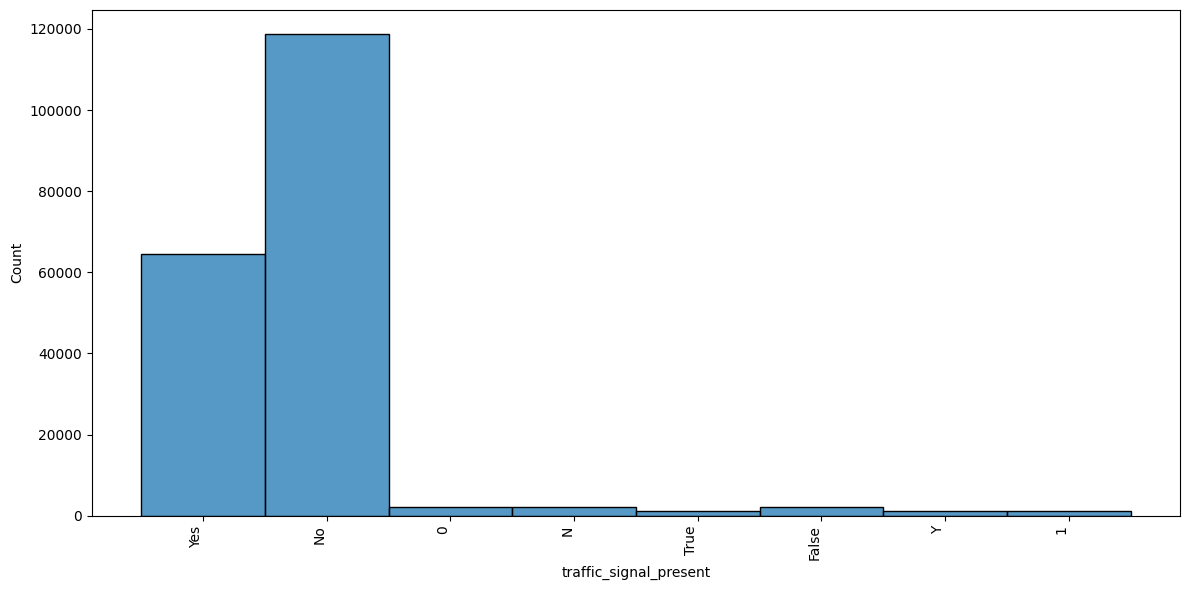

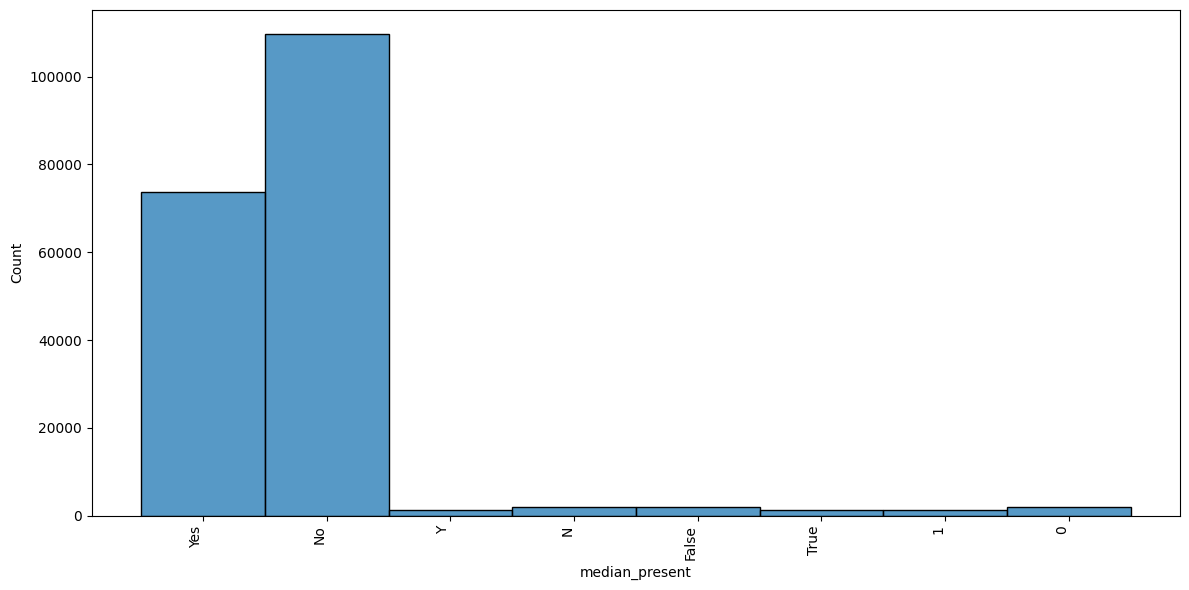

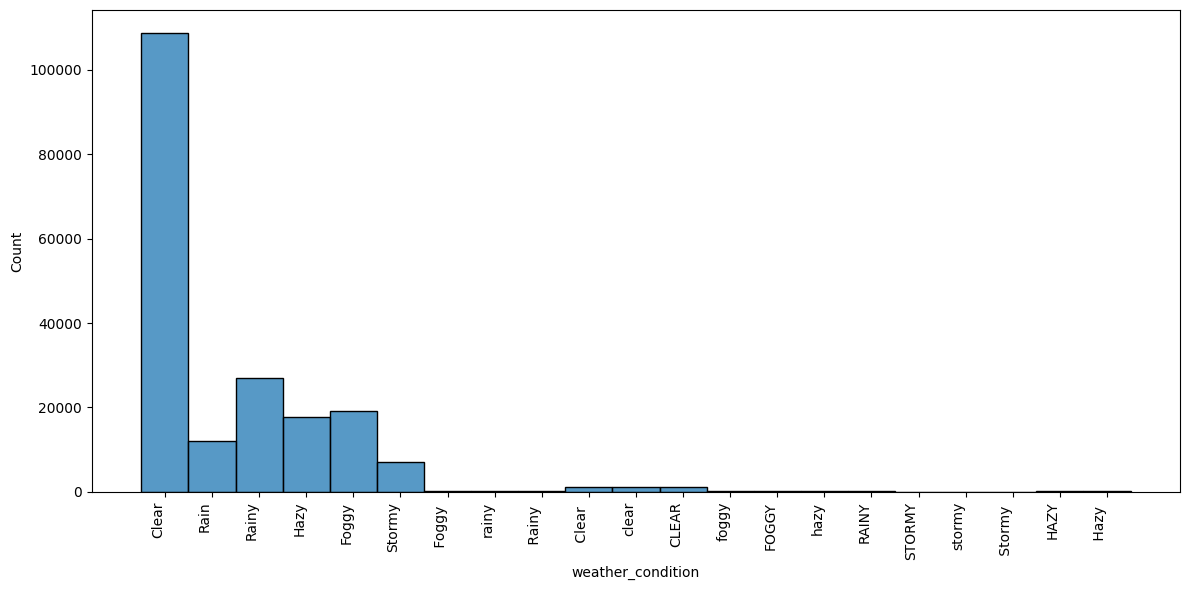

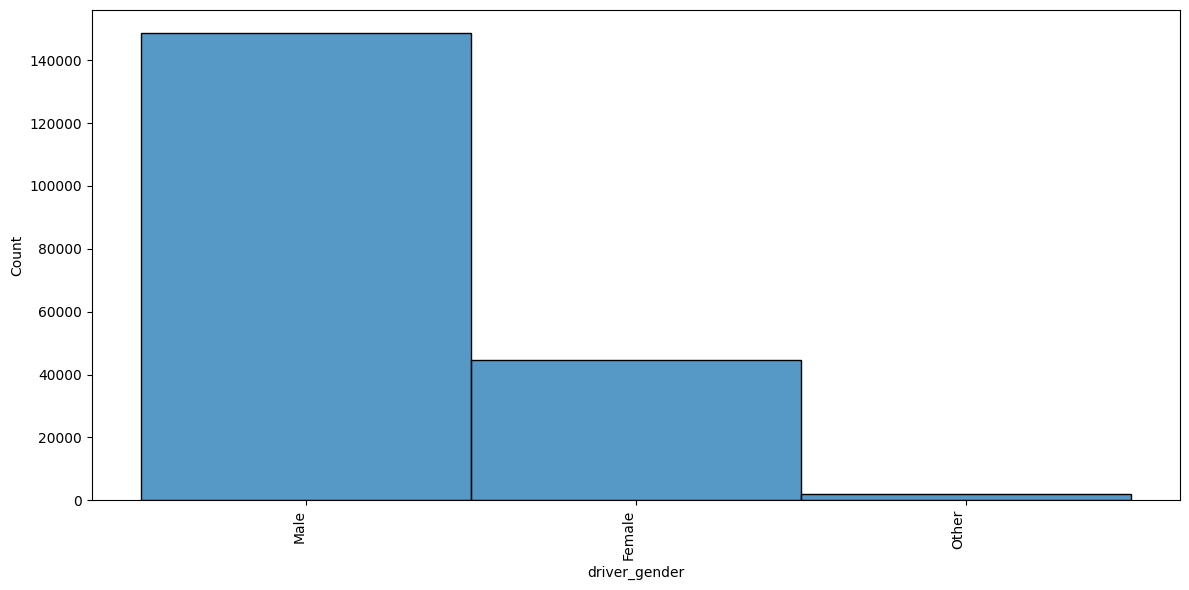

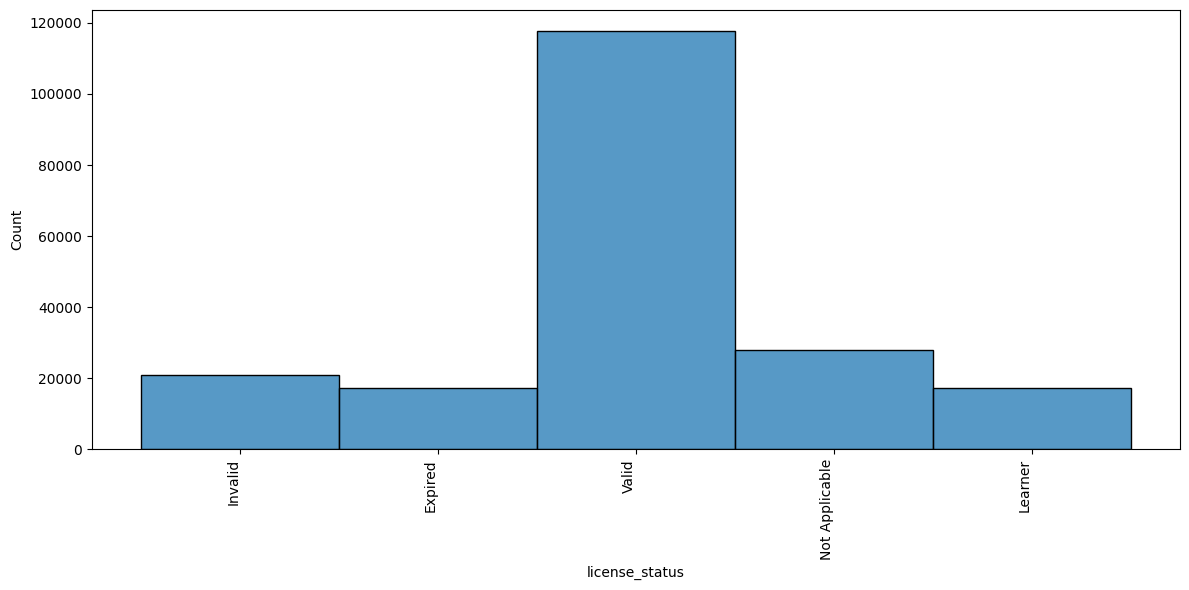

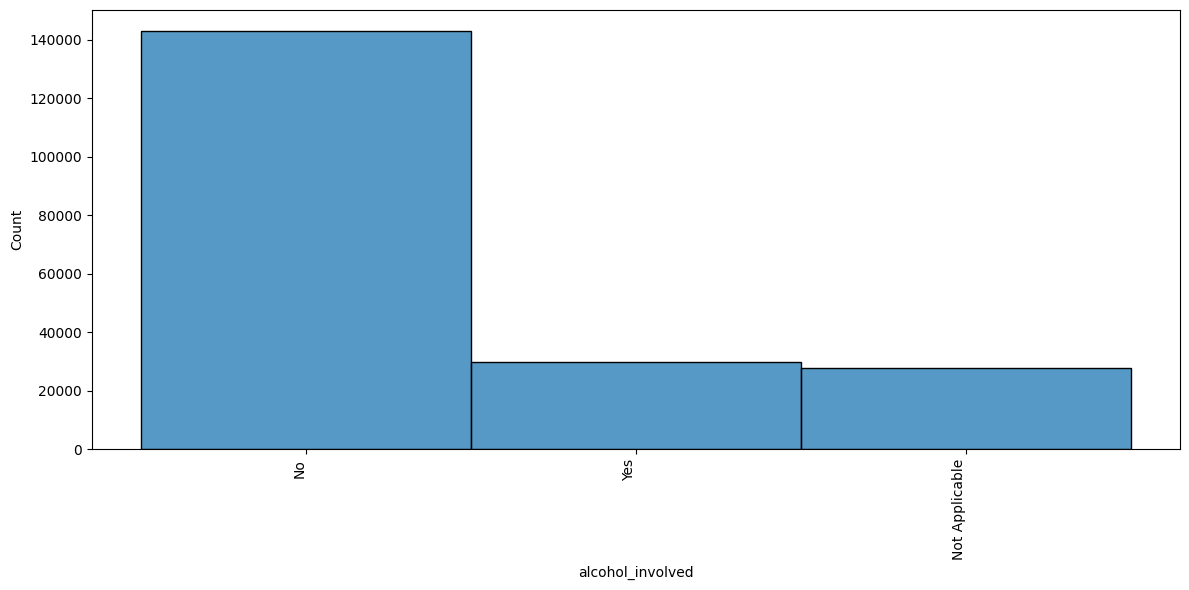

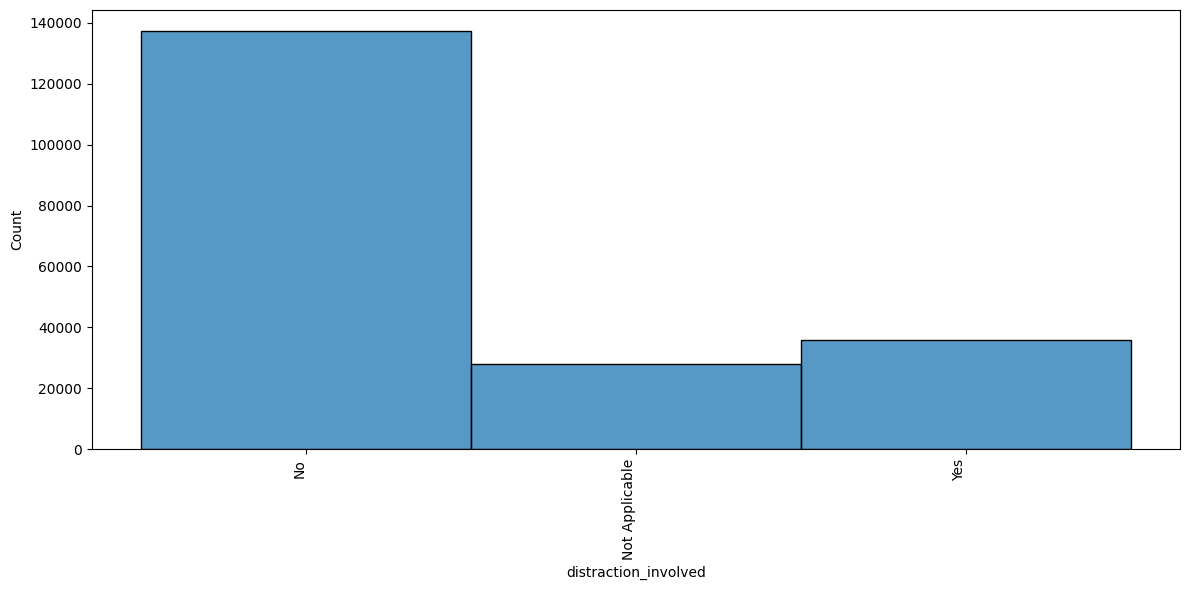

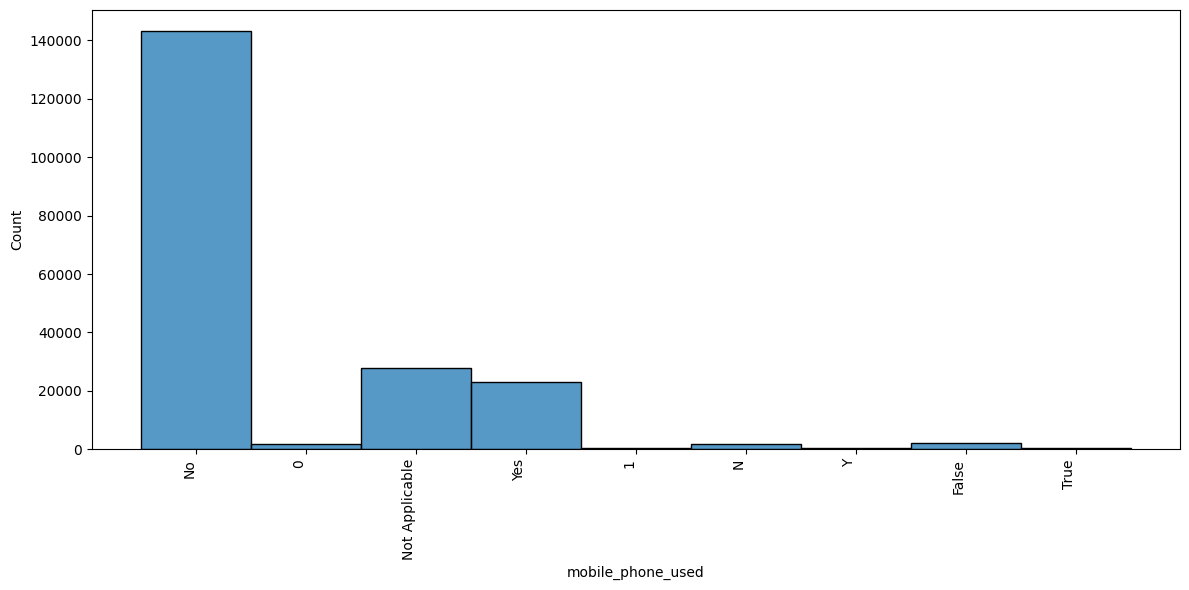

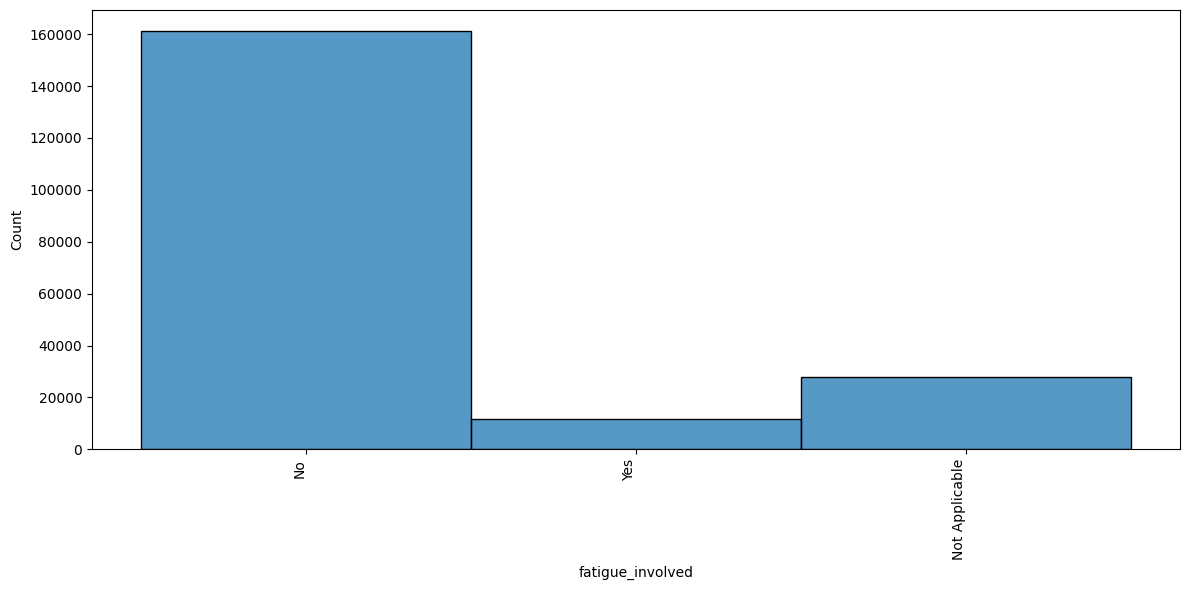

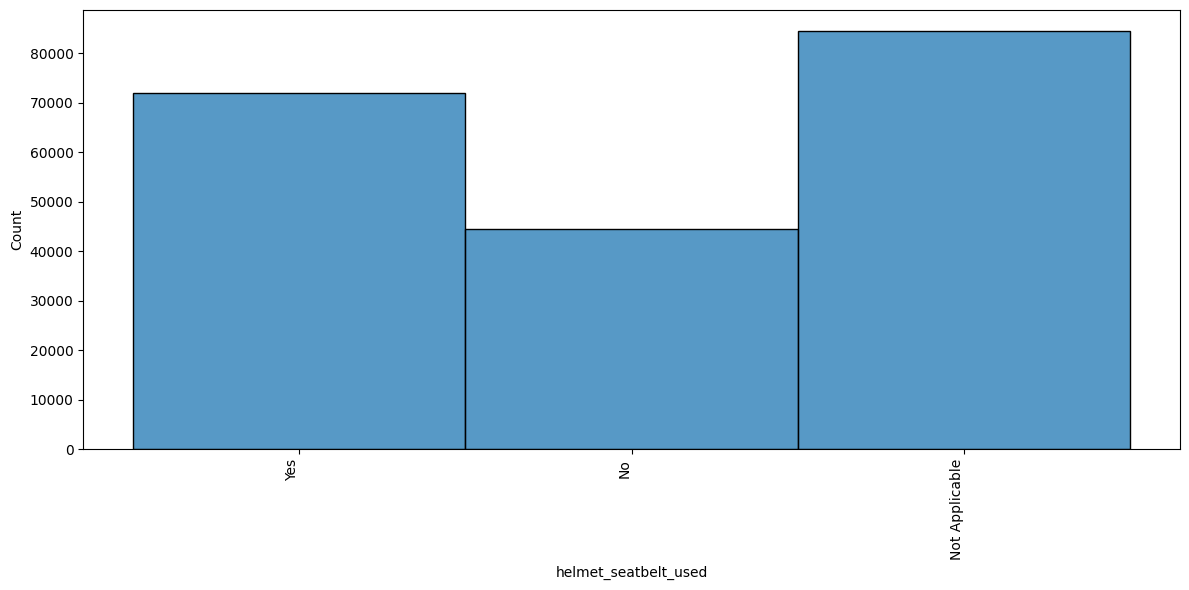

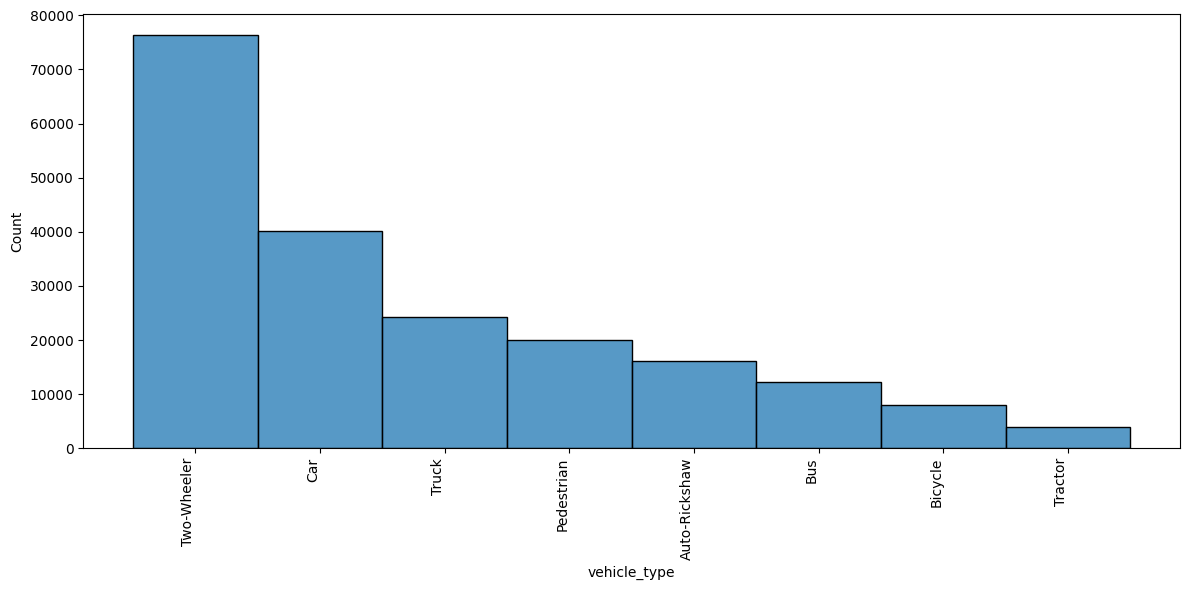

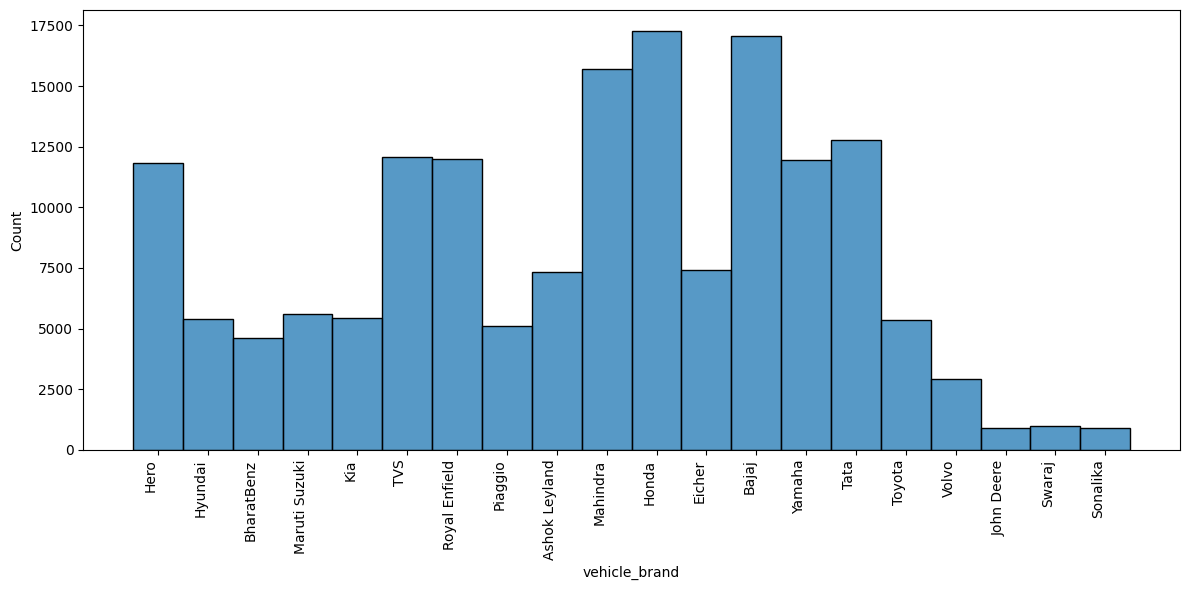

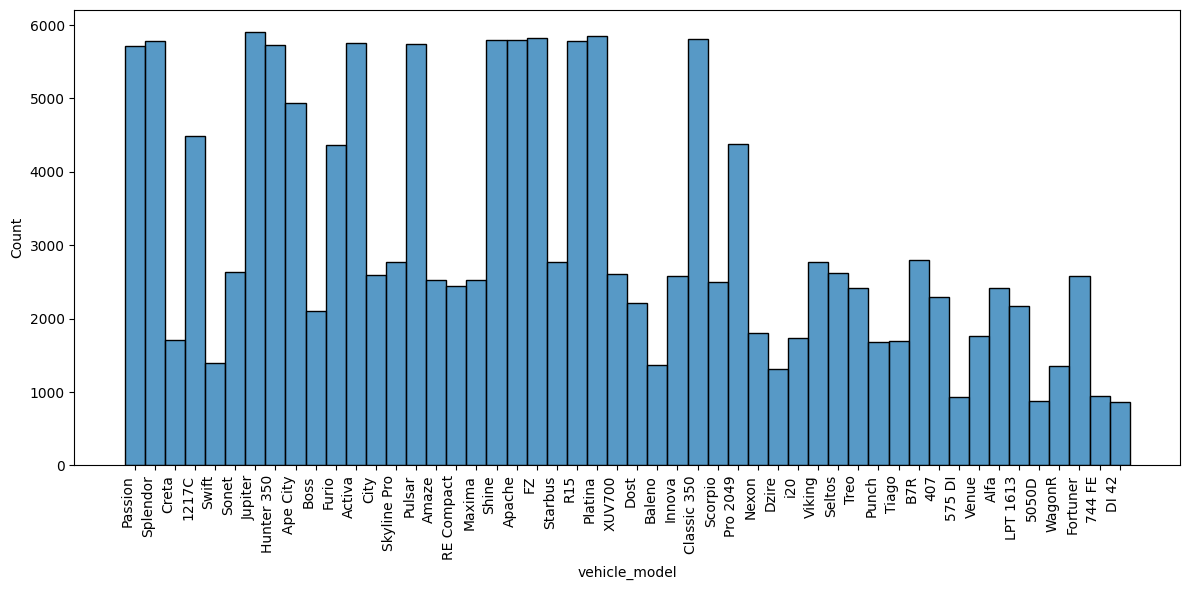

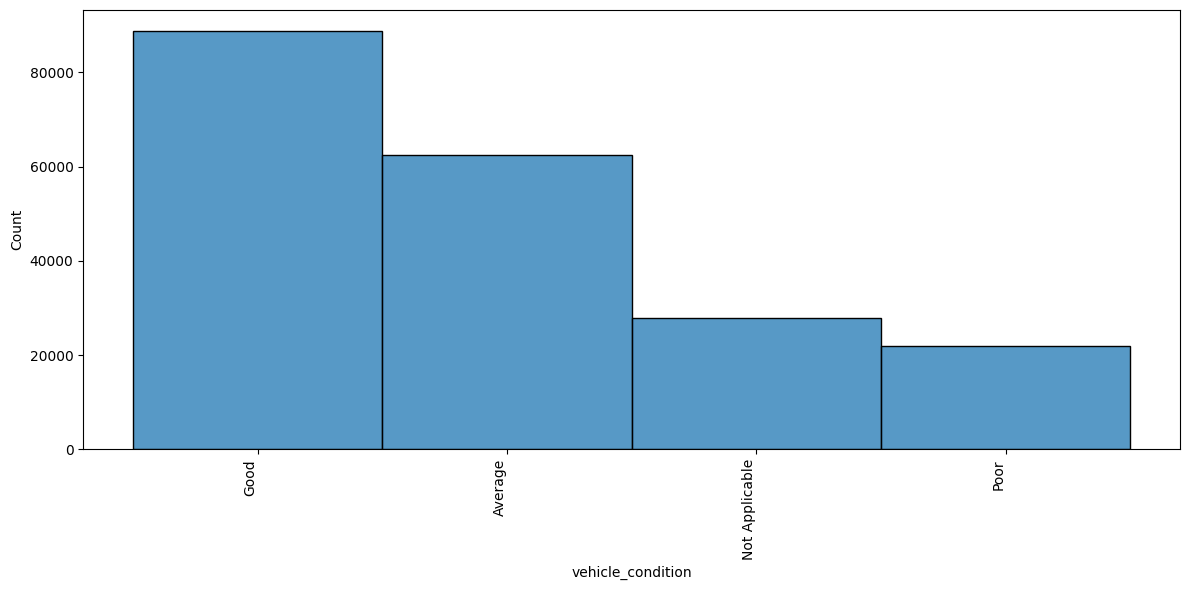

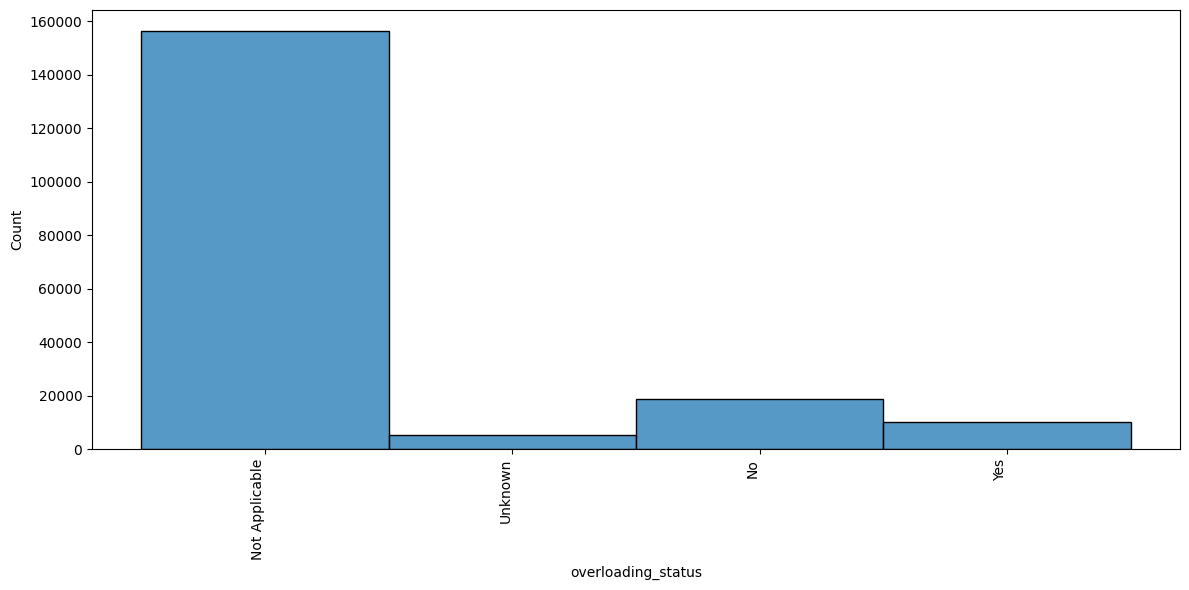

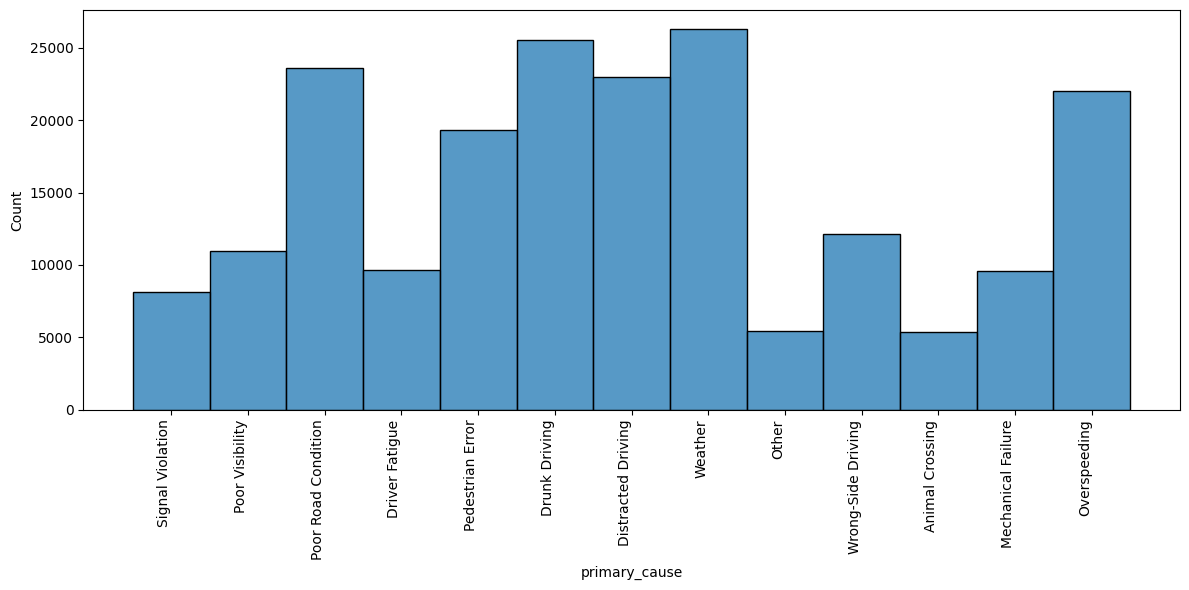

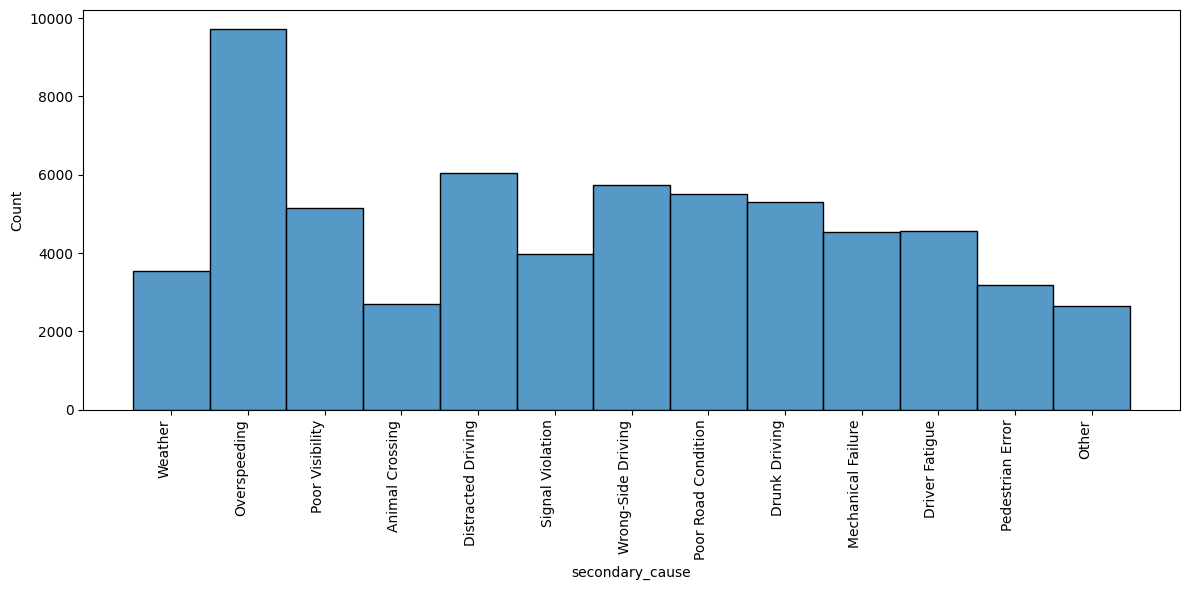

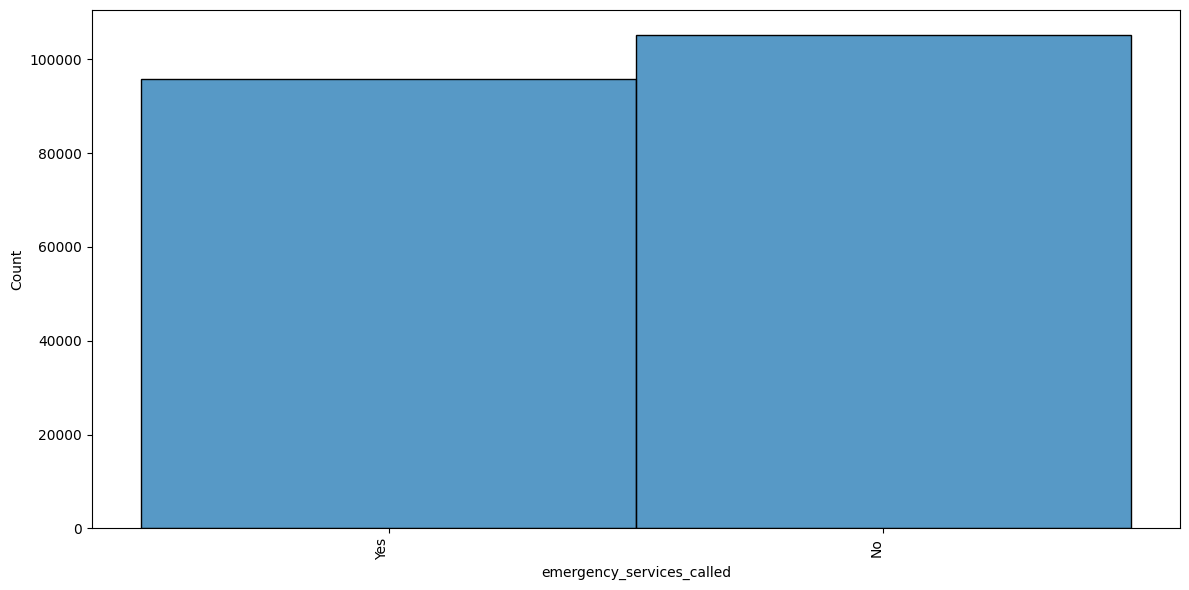

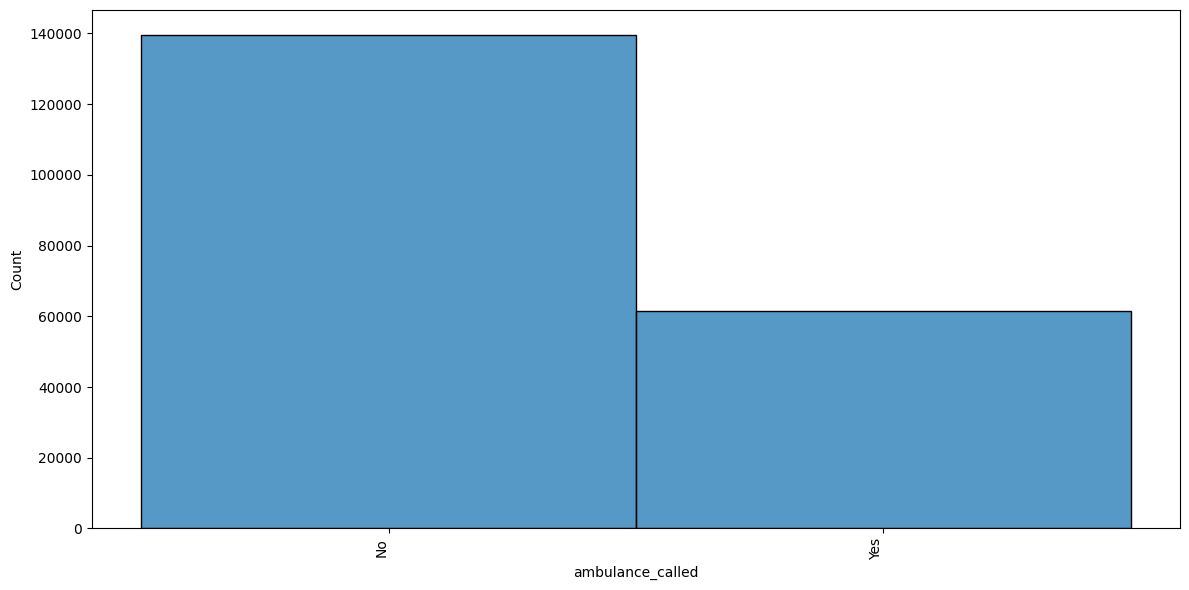

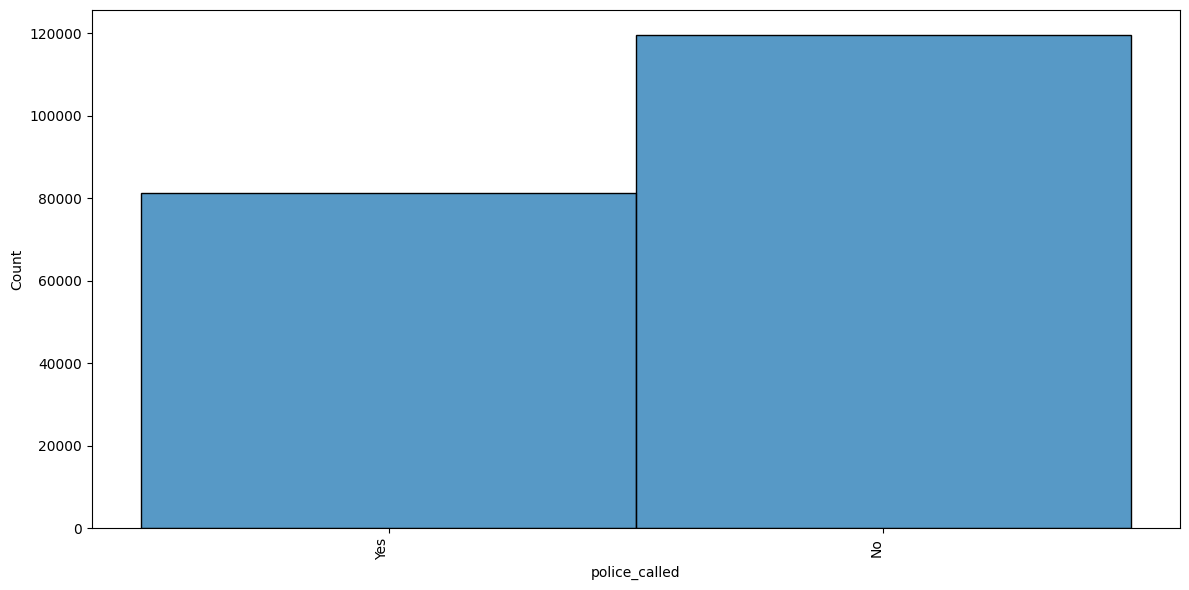

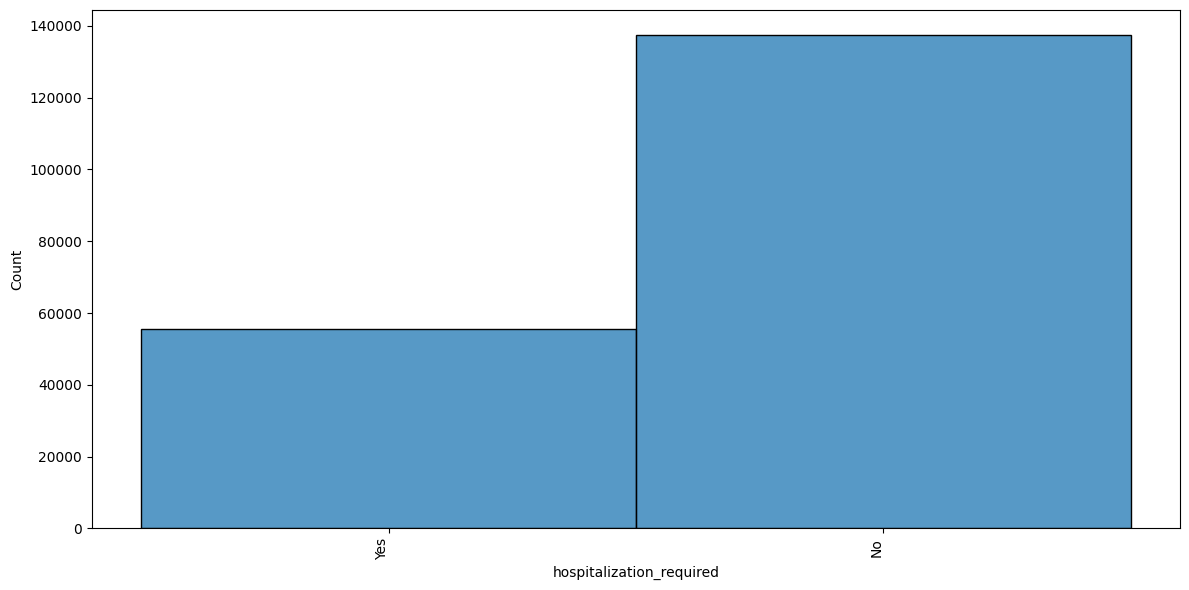

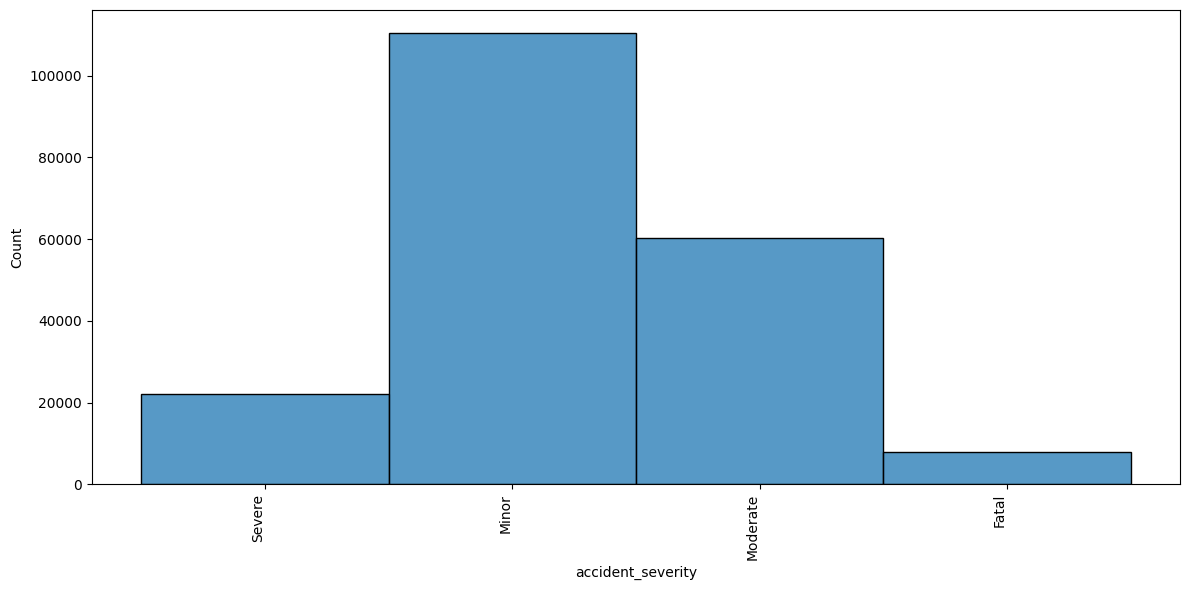

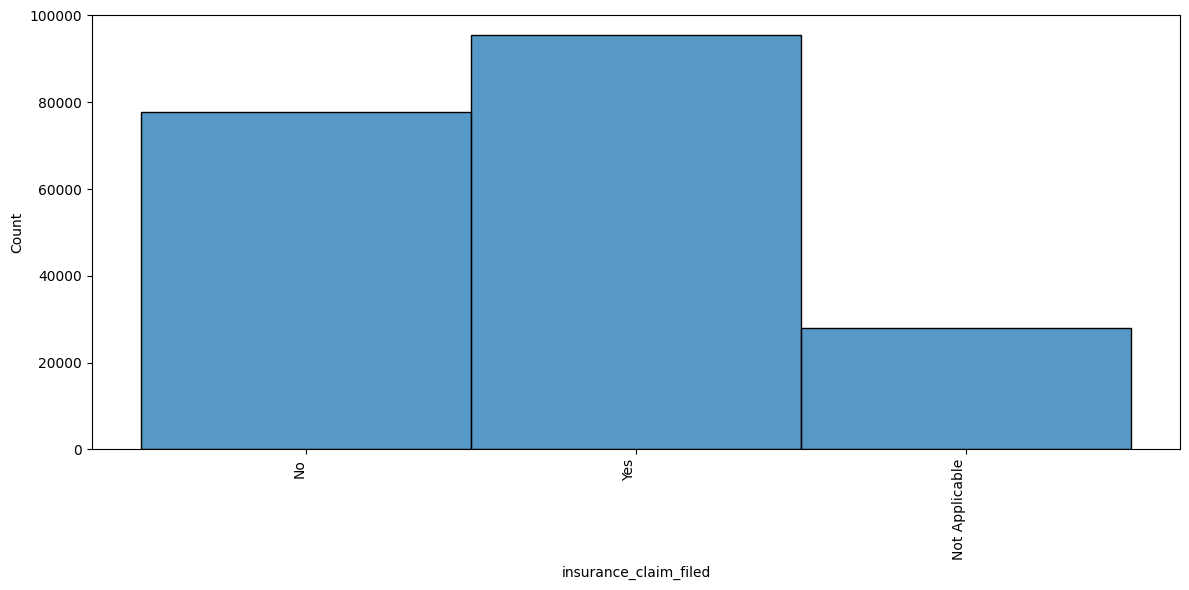

In [79]:
for i in non_num_cols:
    plt.figure(figsize=(12,6))
    sns.histplot(df[i])
    plt.xticks(rotation=90, ha="right")
    plt.tight_layout()


In [74]:
dt.isnull().sum()

0

In [75]:
(df['driving_experience_years']>df['driver_age']).sum()

276

there are 276 person whose driving experience uis greater thantheir age 

<Axes: xlabel='num_fatalities', ylabel='Count'>

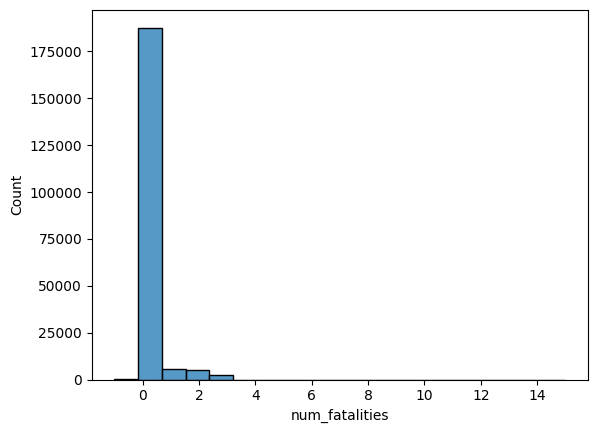

In [76]:
sns.histplot(df['num_fatalities'])

In [77]:
(df['num_fatalities'] < 0).sum()
# there are some (80)rows containing negative number of the fatalities
 

80

In [80]:
for i in ["traffic_signal_present","median_present","mobile_phone_used"]:
    print(df[i].value_counts())

traffic_signal_present
No       118740
Yes       64621
0          2117
N          2100
False      2087
True       1132
Y          1127
1          1064
Name: count, dtype: int64
median_present
No       109684
Yes       73622
0          1929
N          1892
False      1881
True       1337
1          1336
Y          1308
Name: count, dtype: int64
mobile_phone_used
No                143213
Not Applicable     27956
Yes                22913
False               2019
0                   1967
N                   1964
1                    354
Y                    334
True                 300
Name: count, dtype: int64


In [81]:
for i in ["traffic_signal_present","median_present","mobile_phone_used"]:
    df[i] = df[i].map({True:1,False:0,
                       "Yes":1,"No":0,
                       "Y":1,"N":0,
                    "Not Applicable":-1
                       })

here in have standardized the boolean type values to the 1 and 0
and not applicable values to the -1


In [82]:
for i in ["traffic_signal_present","median_present","mobile_phone_used"]:
    print(df[i].value_counts())

traffic_signal_present
0.0    120840
1.0     65748
Name: count, dtype: int64
median_present
0.0    111576
1.0     74930
Name: count, dtype: int64
mobile_phone_used
 0.0    145177
-1.0     27956
 1.0     23247
Name: count, dtype: int64


# Data Cleaning 
